<div style="background:linear-gradient(135deg,#0a0a1a 0%,#0d1117 40%,#0a2a1a 100%);padding:40px 32px;border-radius:12px;color:white;margin-bottom:8px;border:1px solid #30363d;">
  <div style="display:flex;align-items:center;gap:16px;margin-bottom:16px;">
    <span style="font-size:48px;">🌌</span>
    <div>
      <h1 style="margin:0;font-size:28px;font-weight:700;">AstroVision — Phase 3A</h1>
      <p style="margin:4px 0 0;font-size:14px;opacity:0.7;">Cross-match Galaxy10 × SDSS DR16 · Morphologie × Spectroscopie · AstroSymb</p>
    </div>
  </div>
  <hr style="border:none;border-top:1px solid rgba(255,255,255,0.15);margin:16px 0;">
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;font-size:13px;">
    <div><span style="opacity:0.6;">Catalogue</span><br><b>SDSS DR16 via CDS XMatch</b></div>
    <div><span style="opacity:0.6;">Rayon</span><br><b>3 arcsec</b></div>
    <div><span style="opacity:0.6;">Science</span><br><b>Morphologie ↔ Population stellaire</b></div>
    <div><span style="opacity:0.6;">Goal</span><br><b>Lien AstroSpectro × AstroVision</b></div>
  </div>
</div>

## 0 — Setup & Imports

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from scipy import stats
from umap import UMAP
import h5py

from astrovision.data_loader import CLASS_NAMES, H5_PATH
from astrovision.crossmatcher import Galaxy10Crossmatcher
from astrovision.spectral_viz import (
    plot_cmd, plot_color_by_class, plot_umap_spectral,
    plot_feature_correlation, ks_test_classes,
    plot_bpt_proxy, plot_class_summary,
)

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'axes.titlecolor':'#f0f6fc','axes.titlesize':12,
    'axes.titleweight':'bold','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#c9d1d9',
    'grid.color':'#21262d','grid.linewidth':0.7,
    'figure.dpi':150,'savefig.facecolor':'#0d1117',
    'savefig.bbox':'tight','font.size':10,
})
PALETTE = ['#6e40aa','#4c6edb','#23abd8','#1ac7c2','#1ddfa3',
           '#52f667','#aff05b','#e2b72f','#fb8a27','#f83e4b']
FIGURES_DIR  = '../figures/'
FEATURES_NPZ = '../data/dinov2_features.npz'
SEED = 42

print('✓ Imports OK')

✓ Imports OK


## 1 — Cross-match Galaxy10 × SDSS DR16

In [2]:
xm = Galaxy10Crossmatcher(
    h5_path   = H5_PATH,
    cache_dir = '../data/',
    radius_as = 3.0,
)

# Lance le cross-match (ou charge depuis le cache si déjà fait)
print('\nLancement du cross-match SDSS DR16...')
print('(~5-10 min la première fois, instantané ensuite depuis le cache)')
df_sdss = xm.run_sdss()

# Statistiques complètes
xm.stats(df_sdss)
print('\nColonnes disponibles :', list(df_sdss.columns))

✓ Galaxy10 chargé : 17736 galaxies
  Positions valides : 17,736
  Cache dir : C:\Users\alexb\Documents\Projets\AstroVision\data

Lancement du cross-match SDSS DR16...
(~5-10 min la première fois, instantané ensuite depuis le cache)
Could not import regions, which is required for some of the functionalities of this module.

Cross-match vizier:V/154/sdss16
  17,736 sources × rayon 3.0"
  Batches de 5000 — peut prendre quelques minutes...
  Batch 4/4 → 20120 hits
✓ 17,665 correspondances sauvegardées → galaxy10_sdss_xmatch.csv.gz

═══════════════════════════════════════════════════════
  STATISTIQUES DU CROSS-MATCH
═══════════════════════════════════════════════════════
  Galaxy10 total    :  17,736
  Correspondances   :  17,665  (99.6%)
  Non-matchés       :      71

  Par classe morphologique :
    Disturbed                       1076 /  1081  (100%)
    Merging                         1835 /  1853  (99%)
    Round Smooth                    2635 /  2645  (100%)
    In-between Round Smoo

## 2 — Exploration du catalogue croisé

Shape : (17665, 57)

Aperçu :
    angDist  g10_idx          ra        dec  label   z_photo  \
0  0.000068    15222  247.009155  26.053114      8  0.064409   
1  0.000197    17614  211.230423  54.441288      9  0.081925   
2  0.000203    11532  150.875732  30.812729      6  0.082709   
3  0.000254      957  217.765259  35.521069      0  0.013565   
4  0.000266     6981  185.304321  57.955780      3  0.101883   

                 objID     RA_ICRS    DE_ICRS  errHalfMaj  ...       r-i  \
0  1237662642270699952  247.009155  26.053114       0.053  ...  0.514002   
1  1237661387067359390  211.230423  54.441288       0.008  ...  0.534000   
2  1237665099003920522  150.875732  30.812729       0.007  ...  0.373000   
3  1237662663207682260  217.765259  35.521069       0.035  ...  0.153000   
4  1237661418205610190  185.304321  57.955780       0.006  ...  0.402000   

        i-z       u-r  blue_cloud  red_sequence  green_valley    population  \
0  0.374999  2.832998       False          True  

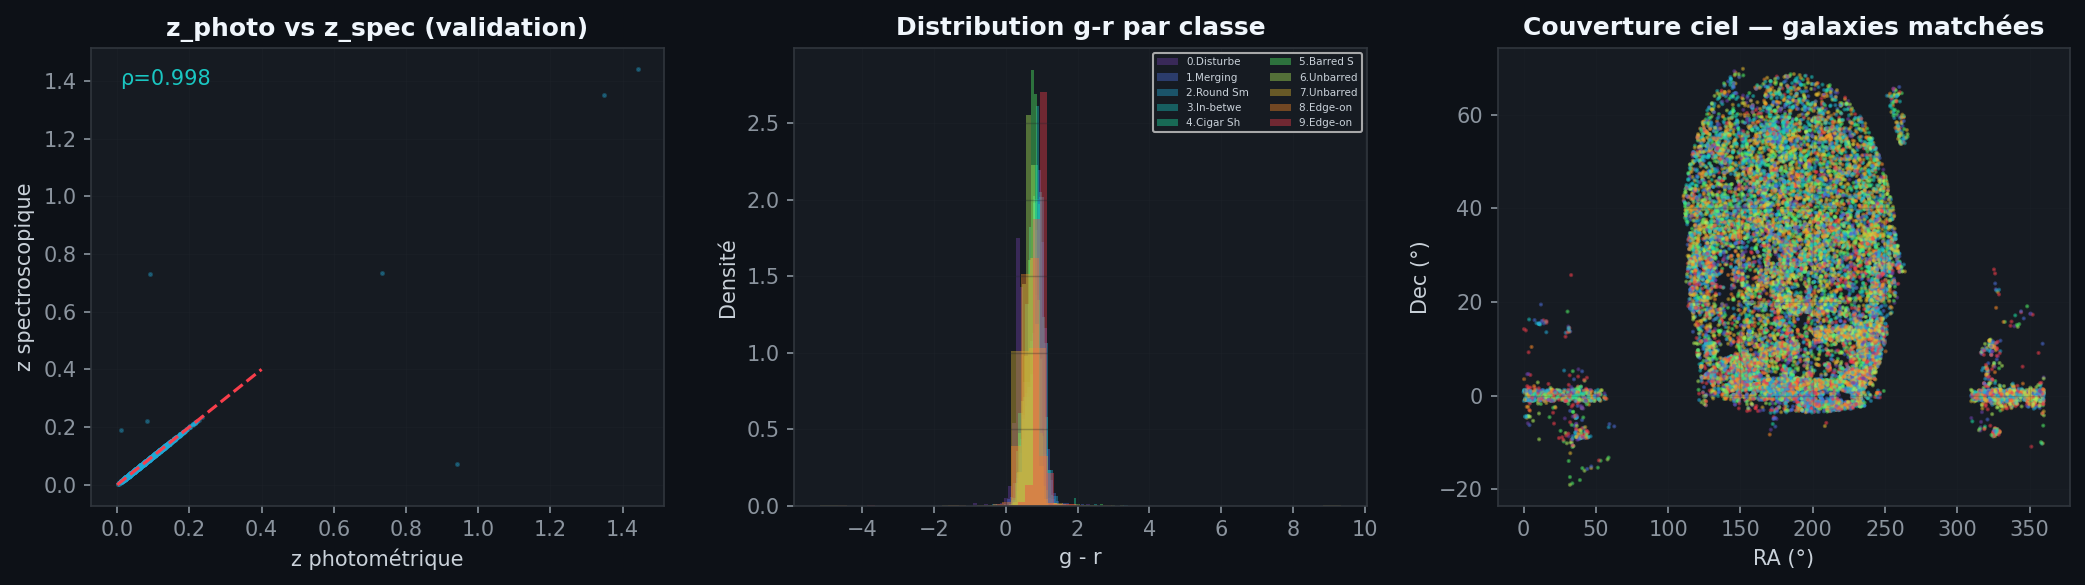

In [3]:
print(f'Shape : {df_sdss.shape}')
print(f'\nAperçu :')
print(df_sdss.head())

# Colonnes numériques disponibles
num_cols = df_sdss.select_dtypes(include=np.number).columns.tolist()
print(f'\nColonnes numériques : {num_cols}')

# Distribution des redshifts spectroscopiques vs photométriques
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)

# Redshift photo vs spectro
if 'zsp' in df_sdss.columns and 'z_photo' in df_sdss.columns:
    sub = df_sdss.dropna(subset=['zsp','z_photo'])
    sub = sub[sub['zsp'] > 0.001]
    axes[0].scatter(sub['z_photo'], sub['zsp'], s=2, alpha=0.3,
                    c='#23abd8', rasterized=True)
    axes[0].plot([0,0.4],[0,0.4], '#f83e4b', lw=1.5, ls='--')
    axes[0].set_xlabel('z photométrique'); axes[0].set_ylabel('z spectroscopique')
    axes[0].set_title('z_photo vs z_spec (validation)'); axes[0].grid(alpha=0.3)
    r = stats.spearmanr(sub['z_photo'], sub['zsp'])[0]
    axes[0].text(0.05, 0.92, f'ρ={r:.3f}', transform=axes[0].transAxes,
                 fontsize=10, color='#1ac7c2')

# Distribution g-r par classe (rapide)
if 'g-r' in df_sdss.columns:
    for i, cls in enumerate(CLASS_NAMES):
        vals = df_sdss.loc[df_sdss['class_name']==cls, 'g-r'].dropna()
        if len(vals) > 3:
            axes[1].hist(vals, bins=30, alpha=0.4, color=PALETTE[i],
                        label=f'{i}.{cls[:8]}', density=True)
    axes[1].set_xlabel('g - r'); axes[1].set_ylabel('Densité')
    axes[1].set_title('Distribution g-r par classe')
    axes[1].legend(fontsize=5, ncol=2)
    axes[1].grid(alpha=0.3)

# Couverture ciel
if 'RAJ2000' in df_sdss.columns or 'ra' in df_sdss.columns:
    ra_col  = 'RAJ2000' if 'RAJ2000' in df_sdss.columns else 'ra'
    dec_col = 'DEJ2000' if 'DEJ2000' in df_sdss.columns else 'dec'
    axes[2].scatter(df_sdss[ra_col], df_sdss[dec_col],
                    c=[PALETTE[l] for l in df_sdss['label'].fillna(0).astype(int)],
                    s=1, alpha=0.4, rasterized=True)
    axes[2].set_xlabel('RA (°)'); axes[2].set_ylabel('Dec (°)')
    axes[2].set_title('Couverture ciel — galaxies matchées')
    axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'xm_overview.png', dpi=150)
plt.show()

## 3 — Diagramme Couleur-Magnitude (CMD)

✓ CMD sauvegardé : ../figures/xm_cmd.png


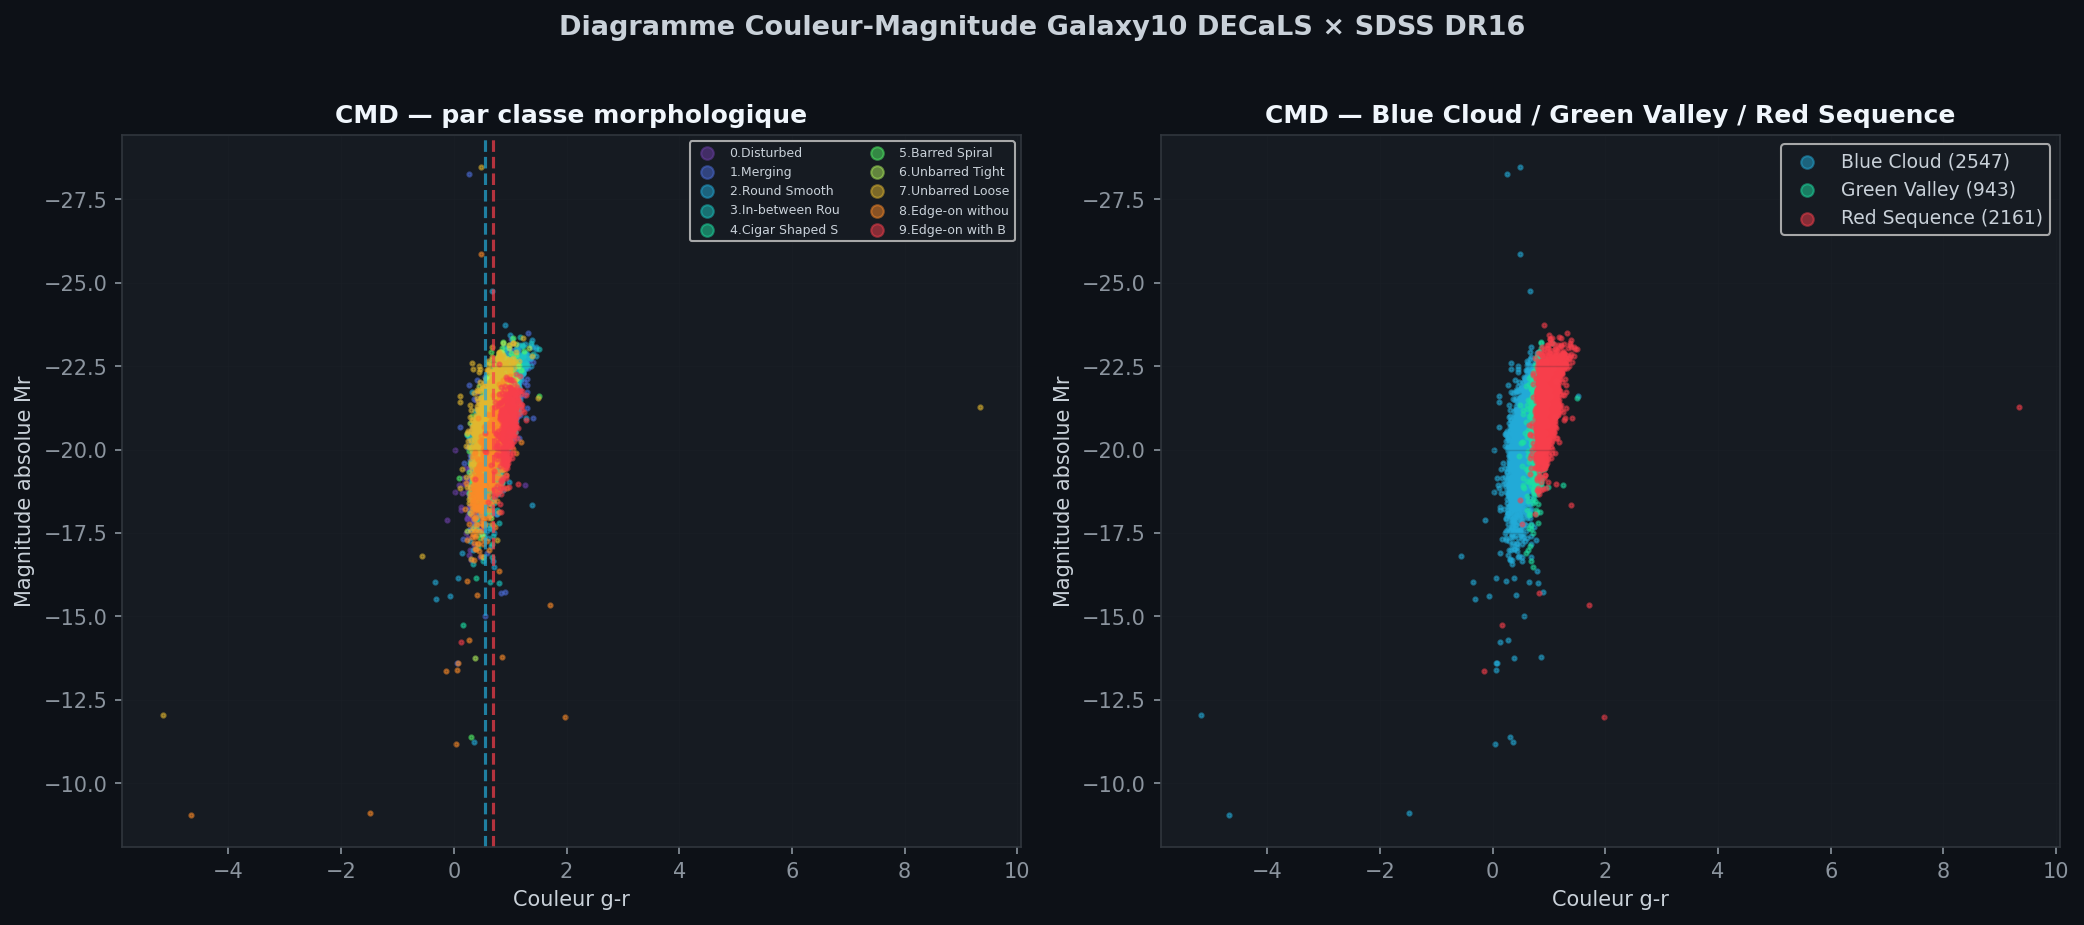

✓ CMD généré avec g-r vs Mr
  5651 galaxies plotées


In [4]:
# Déterminer les meilleures colonnes disponibles
color_col = 'g-r' if 'g-r' in df_sdss.columns else 'u-r' if 'u-r' in df_sdss.columns else None
mag_col   = 'Mr' if 'Mr' in df_sdss.columns else 'rmag' if 'rmag' in df_sdss.columns else None

if color_col and mag_col:
    fig = plot_cmd(df_sdss, color_col=color_col, mag_col=mag_col,
                   save_path=FIGURES_DIR + 'xm_cmd.png')
    plt.show()
    print(f'✓ CMD généré avec {color_col} vs {mag_col}')
    print(f'  {df_sdss.dropna(subset=[color_col,mag_col]).shape[0]} galaxies plotées')
else:
    print(f'⚠ Colonnes disponibles : {list(df_sdss.columns[:20])}')
    print('  Adapte color_col / mag_col selon les colonnes retournées par XMatch')

## 4 — Distribution des couleurs par classe morphologique

✓ Figure sauvegardée : ../figures/xm_color_by_class.png


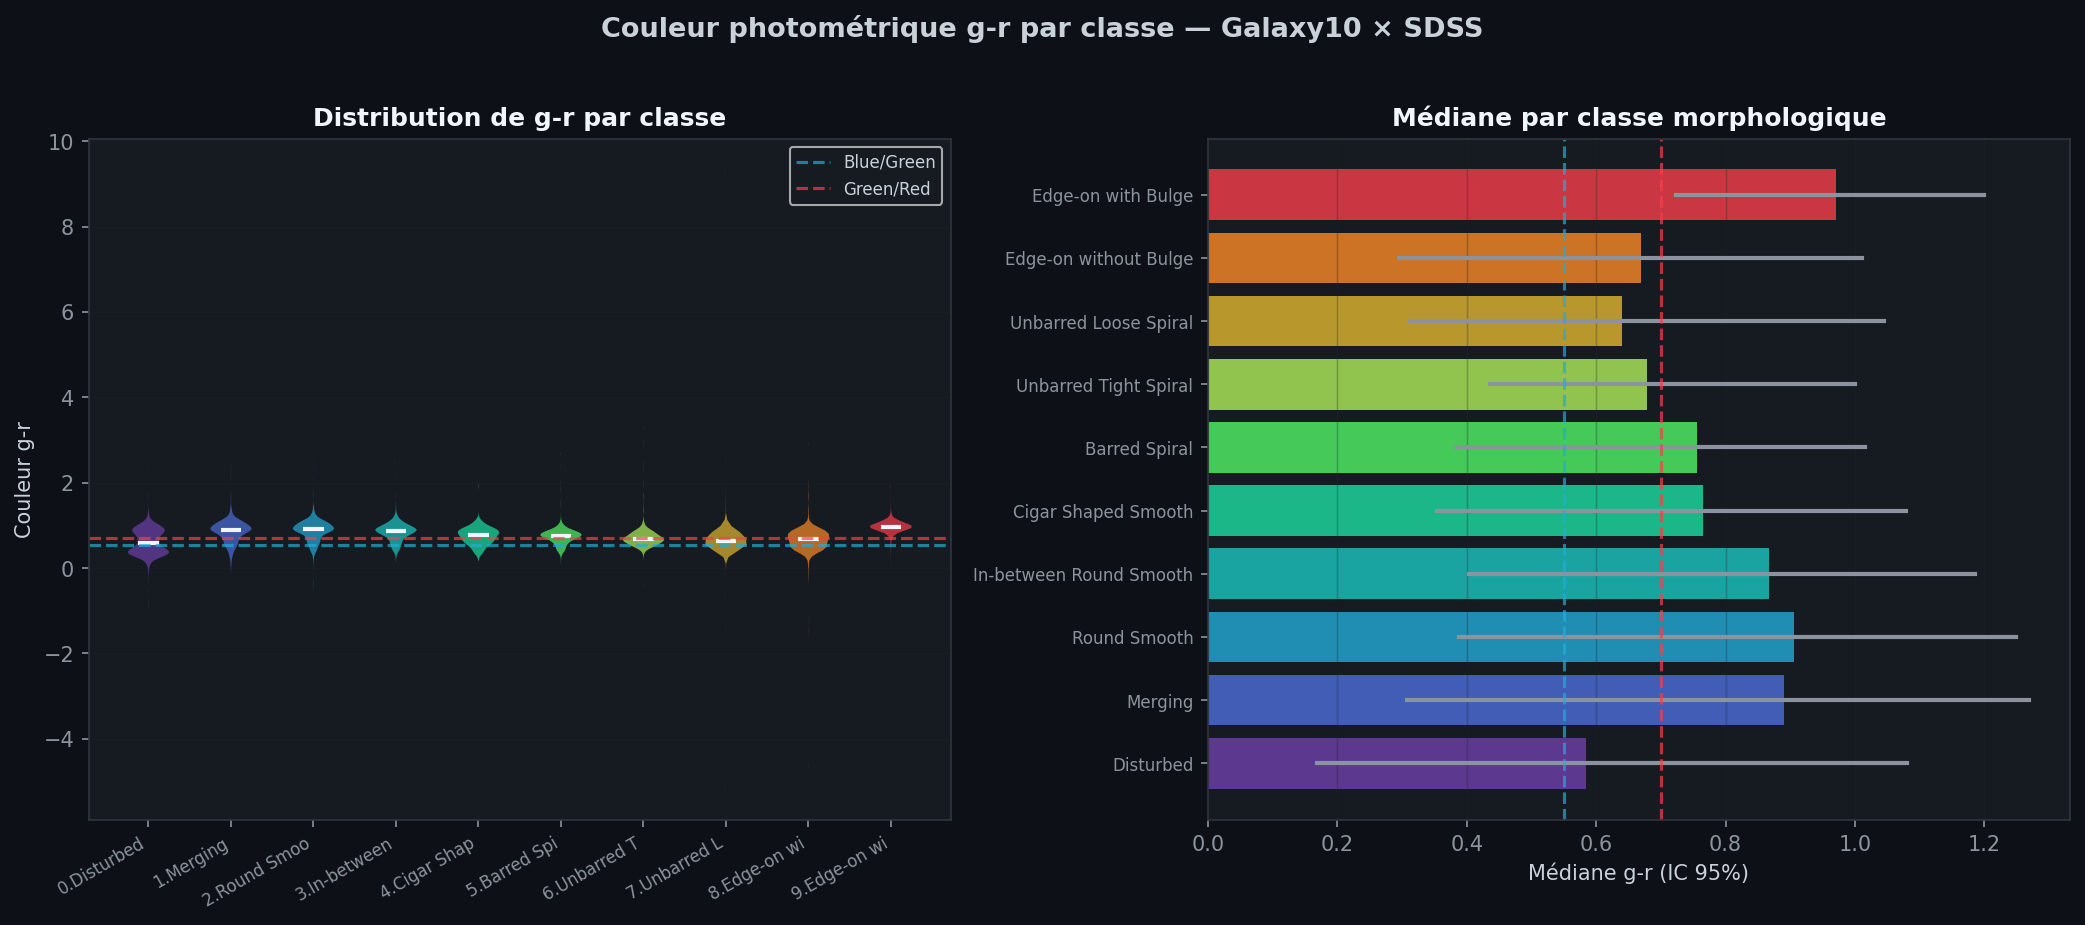


Top 10 paires les plus distinguables par g-r :
              class_1               class_2  ks_stat  p_value  significant   n1   n2
Unbarred Tight Spiral    Edge-on with Bulge   0.7416      0.0         True 1792 1839
Unbarred Loose Spiral    Edge-on with Bulge   0.7348      0.0         True 2594 1839
Edge-on without Bulge    Edge-on with Bulge   0.6980      0.0         True 1395 1839
        Barred Spiral    Edge-on with Bulge   0.6635      0.0         True 2017 1839
            Disturbed    Edge-on with Bulge   0.6155      0.0         True 1066 1839
  Cigar Shaped Smooth    Edge-on with Bulge   0.5693      0.0         True  331 1839
         Round Smooth Unbarred Tight Spiral   0.4957      0.0         True 2590 1792
         Round Smooth Unbarred Loose Spiral   0.4872      0.0         True 2590 2594
              Merging Unbarred Tight Spiral   0.4593      0.0         True 1803 1792
              Merging Unbarred Loose Spiral   0.4518      0.0         True 1803 2594

Paires significa

In [5]:
if color_col:
    fig = plot_color_by_class(df_sdss, color_col=color_col,
                              save_path=FIGURES_DIR + 'xm_color_by_class.png')
    plt.show()

    # Test statistique KS : quelles classes sont distinguables par la couleur?
    df_ks = ks_test_classes(df_sdss, color_col=color_col)
    print(f'\nTop 10 paires les plus distinguables par {color_col} :')
    print(df_ks.head(10).to_string(index=False))
    print(f'\nPaires significativement différentes (p<0.01) : {df_ks["significant"].sum()}/{len(df_ks)}')
else:
    print('⚠ Colonne couleur non disponible')

## 5 — Blue Cloud / Green Valley / Red Sequence

Distribution globale des populations stellaires :
  Blue Cloud      : 7,357  (41.6%)  ████████████████████
  Red Sequence    : 7,104  (40.2%)  ████████████████████
  Green Valley    : 3,204  (18.1%)  █████████

Fraction par classe morphologique :
  Disturbed                      BC=0.61  GV=0.13  RS=0.26
  Merging                        BC=0.28  GV=0.15  RS=0.58
  Round Smooth                   BC=0.23  GV=0.13  RS=0.63
  In-between Round Smooth        BC=0.26  GV=0.16  RS=0.58
  Cigar Shaped Smooth            BC=0.43  GV=0.23  RS=0.33
  Barred Spiral                  BC=0.48  GV=0.31  RS=0.20
  Unbarred Tight Spiral          BC=0.65  GV=0.21  RS=0.14
  Unbarred Loose Spiral          BC=0.71  GV=0.17  RS=0.12
  Edge-on without Bulge          BC=0.58  GV=0.26  RS=0.17
  Edge-on with Bulge             BC=0.03  GV=0.11  RS=0.85


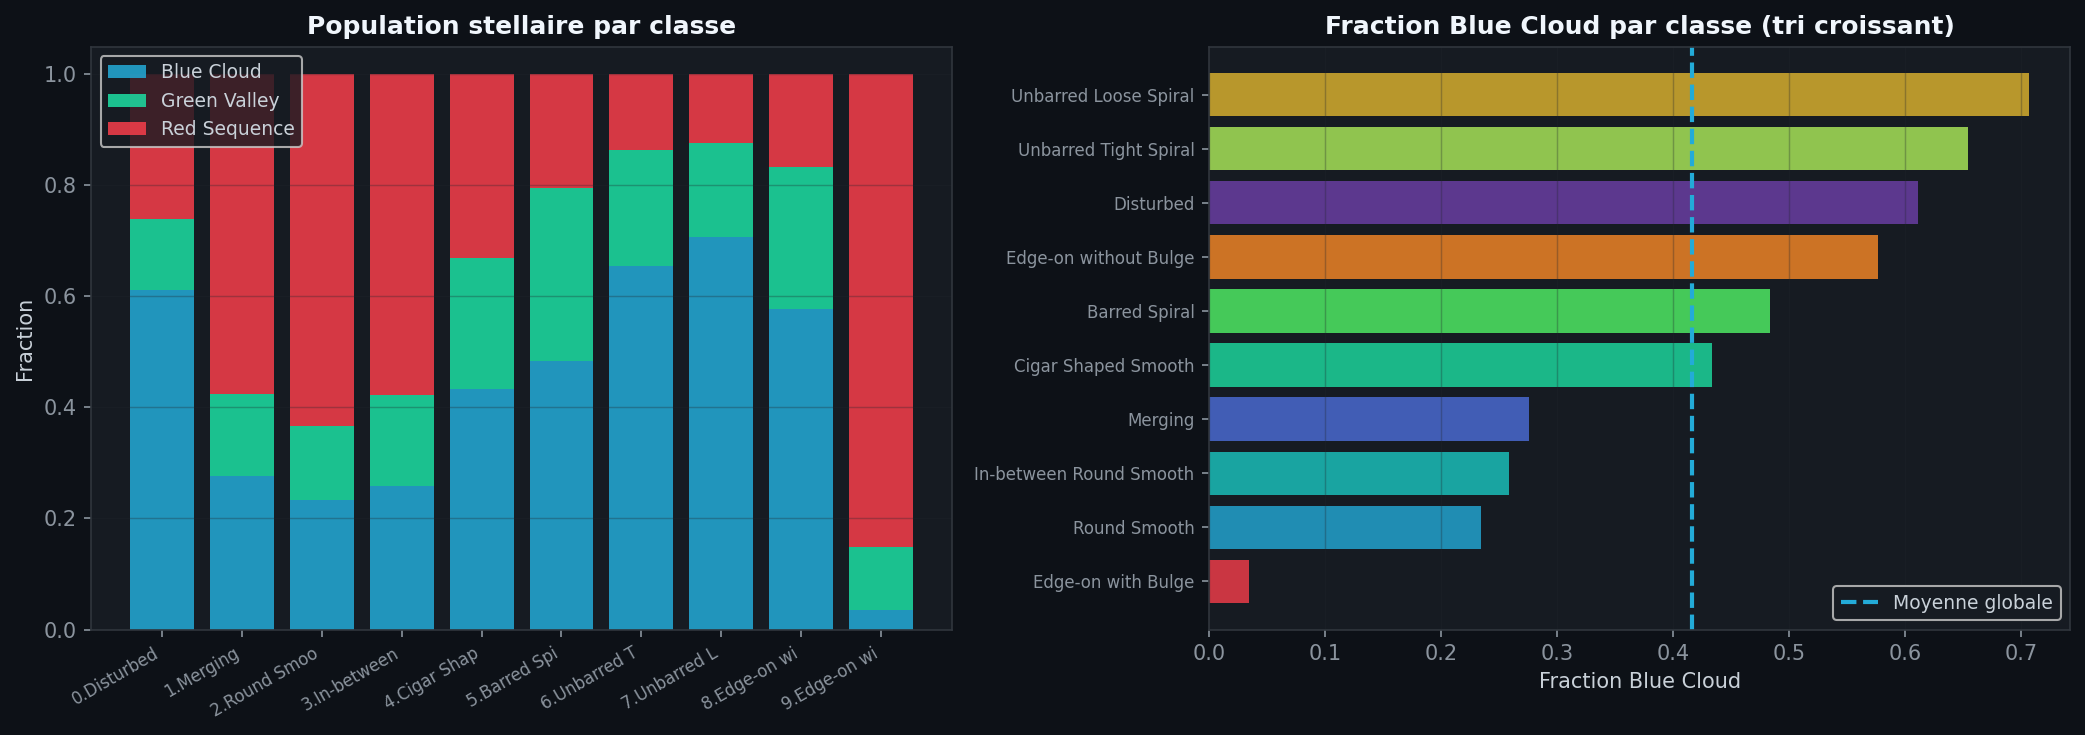


💡 Résultat attendu : Merging/Disturbed → plus Blue Cloud (SFR élevé)
   Elliptiques (Round Smooth) → plus Red Sequence (quiescentes)


In [6]:
if 'population' in df_sdss.columns:
    pop_counts = df_sdss['population'].value_counts()
    print('Distribution globale des populations stellaires :')
    for pop, n in pop_counts.items():
        pct = n / len(df_sdss) * 100
        bar = '█' * int(pct / 2)
        print(f'  {pop:<15} : {n:>5,}  ({pct:.1f}%)  {bar}')

    print('\nFraction par classe morphologique :')
    pop_by_class = df_sdss.groupby(['class_name','population']).size().unstack(fill_value=0)
    pop_by_class = pop_by_class.div(pop_by_class.sum(axis=1), axis=0)
    for cls in CLASS_NAMES:
        if cls in pop_by_class.index:
            row = pop_by_class.loc[cls]
            bc = row.get('Blue Cloud', 0)
            gv = row.get('Green Valley', 0)
            rs = row.get('Red Sequence', 0)
            print(f'  {cls:<30} BC={bc:.2f}  GV={gv:.2f}  RS={rs:.2f}')

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    # Barplot empilé
    ax = axes[0]
    classes_ok = [c for c in CLASS_NAMES if c in pop_by_class.index]
    pop_order  = ['Blue Cloud', 'Green Valley', 'Red Sequence']
    pop_cols   = ['#23abd8', '#1ddfa3', '#f83e4b']
    bottom = np.zeros(len(classes_ok))
    for pop, col in zip(pop_order, pop_cols):
        if pop in pop_by_class.columns:
            vals = [pop_by_class.loc[c, pop] if c in pop_by_class.index else 0
                    for c in classes_ok]
            ax.bar(range(len(classes_ok)), vals, bottom=bottom,
                   color=col, alpha=0.85, label=pop, edgecolor='none')
            bottom += np.array(vals)
    ax.set_xticks(range(len(classes_ok)))
    ax.set_xticklabels([f'{CLASS_NAMES.index(c)}.{c[:10]}'
                        for c in classes_ok], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Fraction'); ax.set_title('Population stellaire par classe')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    # Fraction Blue Cloud seulement (ordonnée)
    ax2 = axes[1]
    if 'Blue Cloud' in pop_by_class.columns:
        bc_frac = pop_by_class['Blue Cloud'].reindex(CLASS_NAMES).dropna().sort_values()
        colors  = [PALETTE[CLASS_NAMES.index(c)] for c in bc_frac.index]
        ax2.barh(range(len(bc_frac)), bc_frac.values, color=colors, alpha=0.8, edgecolor='none')
        ax2.set_yticks(range(len(bc_frac)))
        ax2.set_yticklabels(bc_frac.index, fontsize=8)
        ax2.set_xlabel('Fraction Blue Cloud')
        ax2.set_title('Fraction Blue Cloud par classe (tri croissant)')
        ax2.axvline(pop_counts.get('Blue Cloud',0)/len(df_sdss),
                    color='#23abd8', lw=2, ls='--', label='Moyenne globale')
        ax2.legend(fontsize=9); ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'xm_populations.png', dpi=150)
    plt.show()
    print('\n💡 Résultat attendu : Merging/Disturbed → plus Blue Cloud (SFR élevé)')
    print('   Elliptiques (Round Smooth) → plus Red Sequence (quiescentes)')
else:
    print('⚠ Colonne population absente — u-r requis')

## 6 — Diagramme couleur-couleur proxy (pseudo-BPT)

✓ BPT proxy sauvegardé : ../figures/xm_bpt_proxy.png


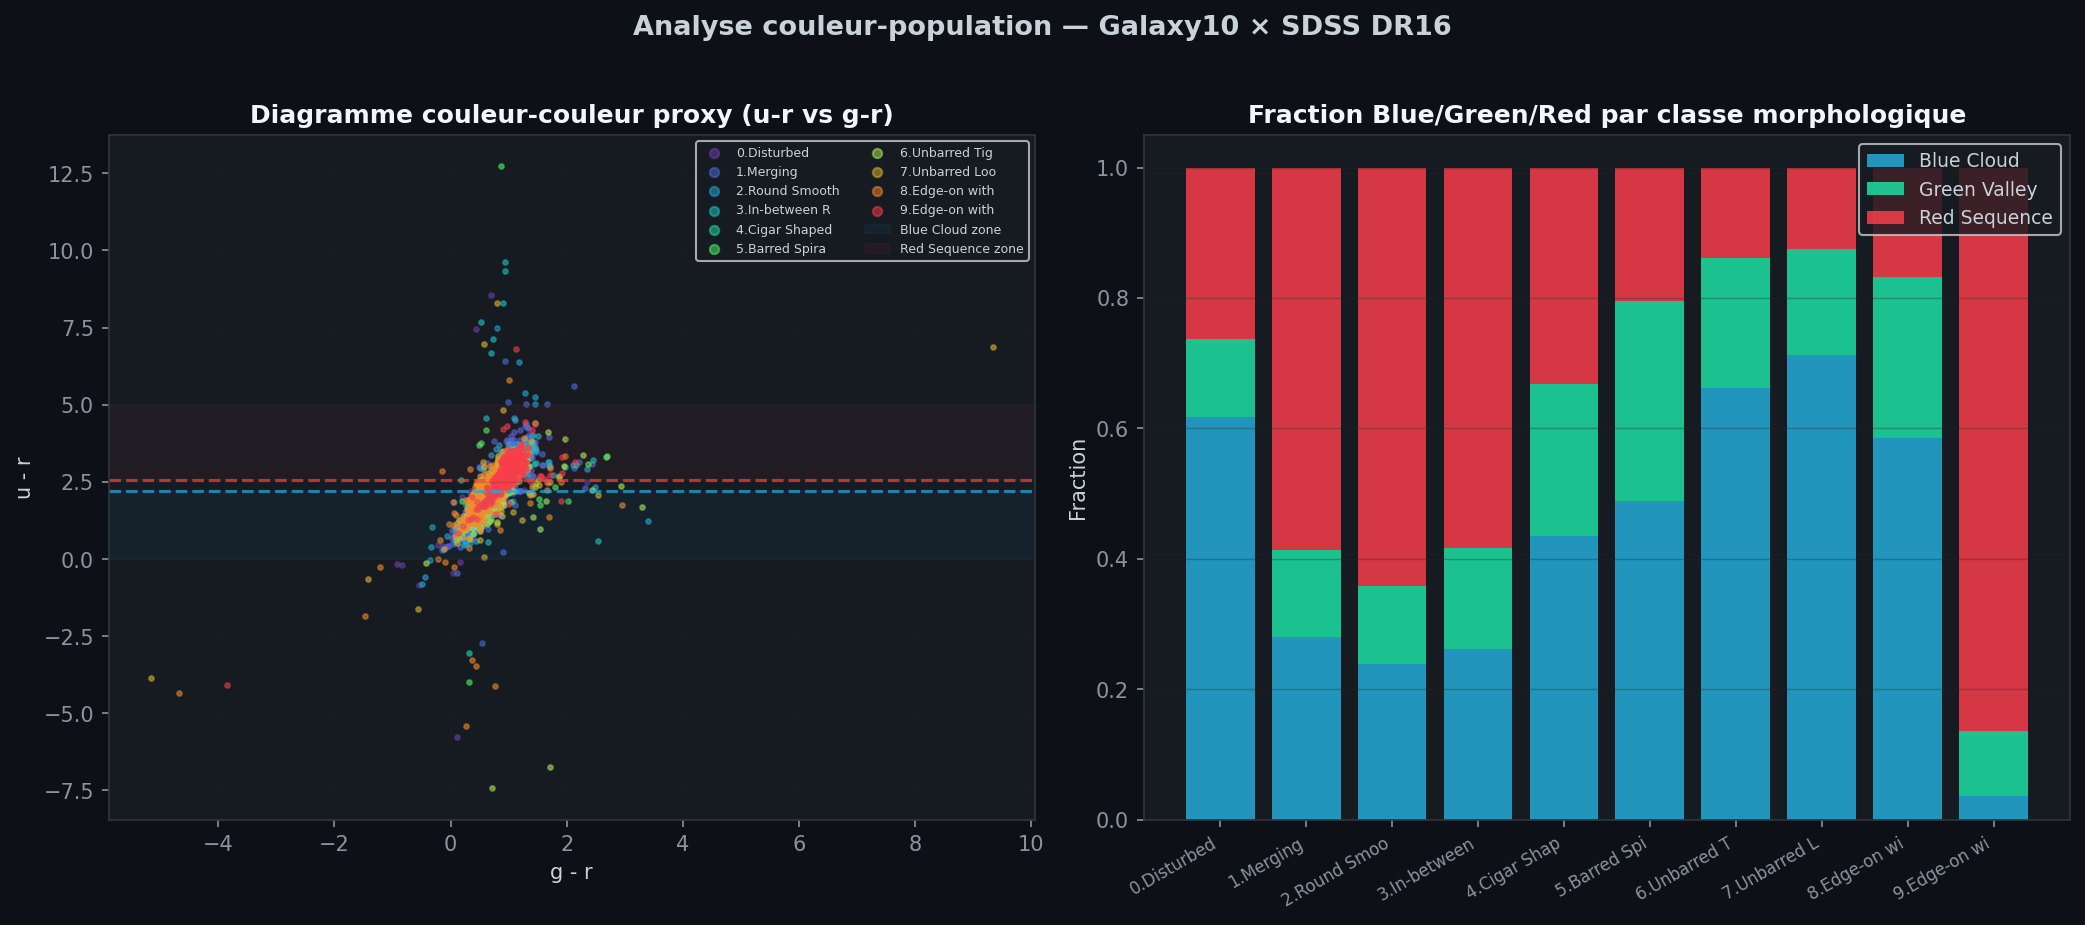

✓ Résumé par classe sauvegardé : ../figures/xm_class_summary.png


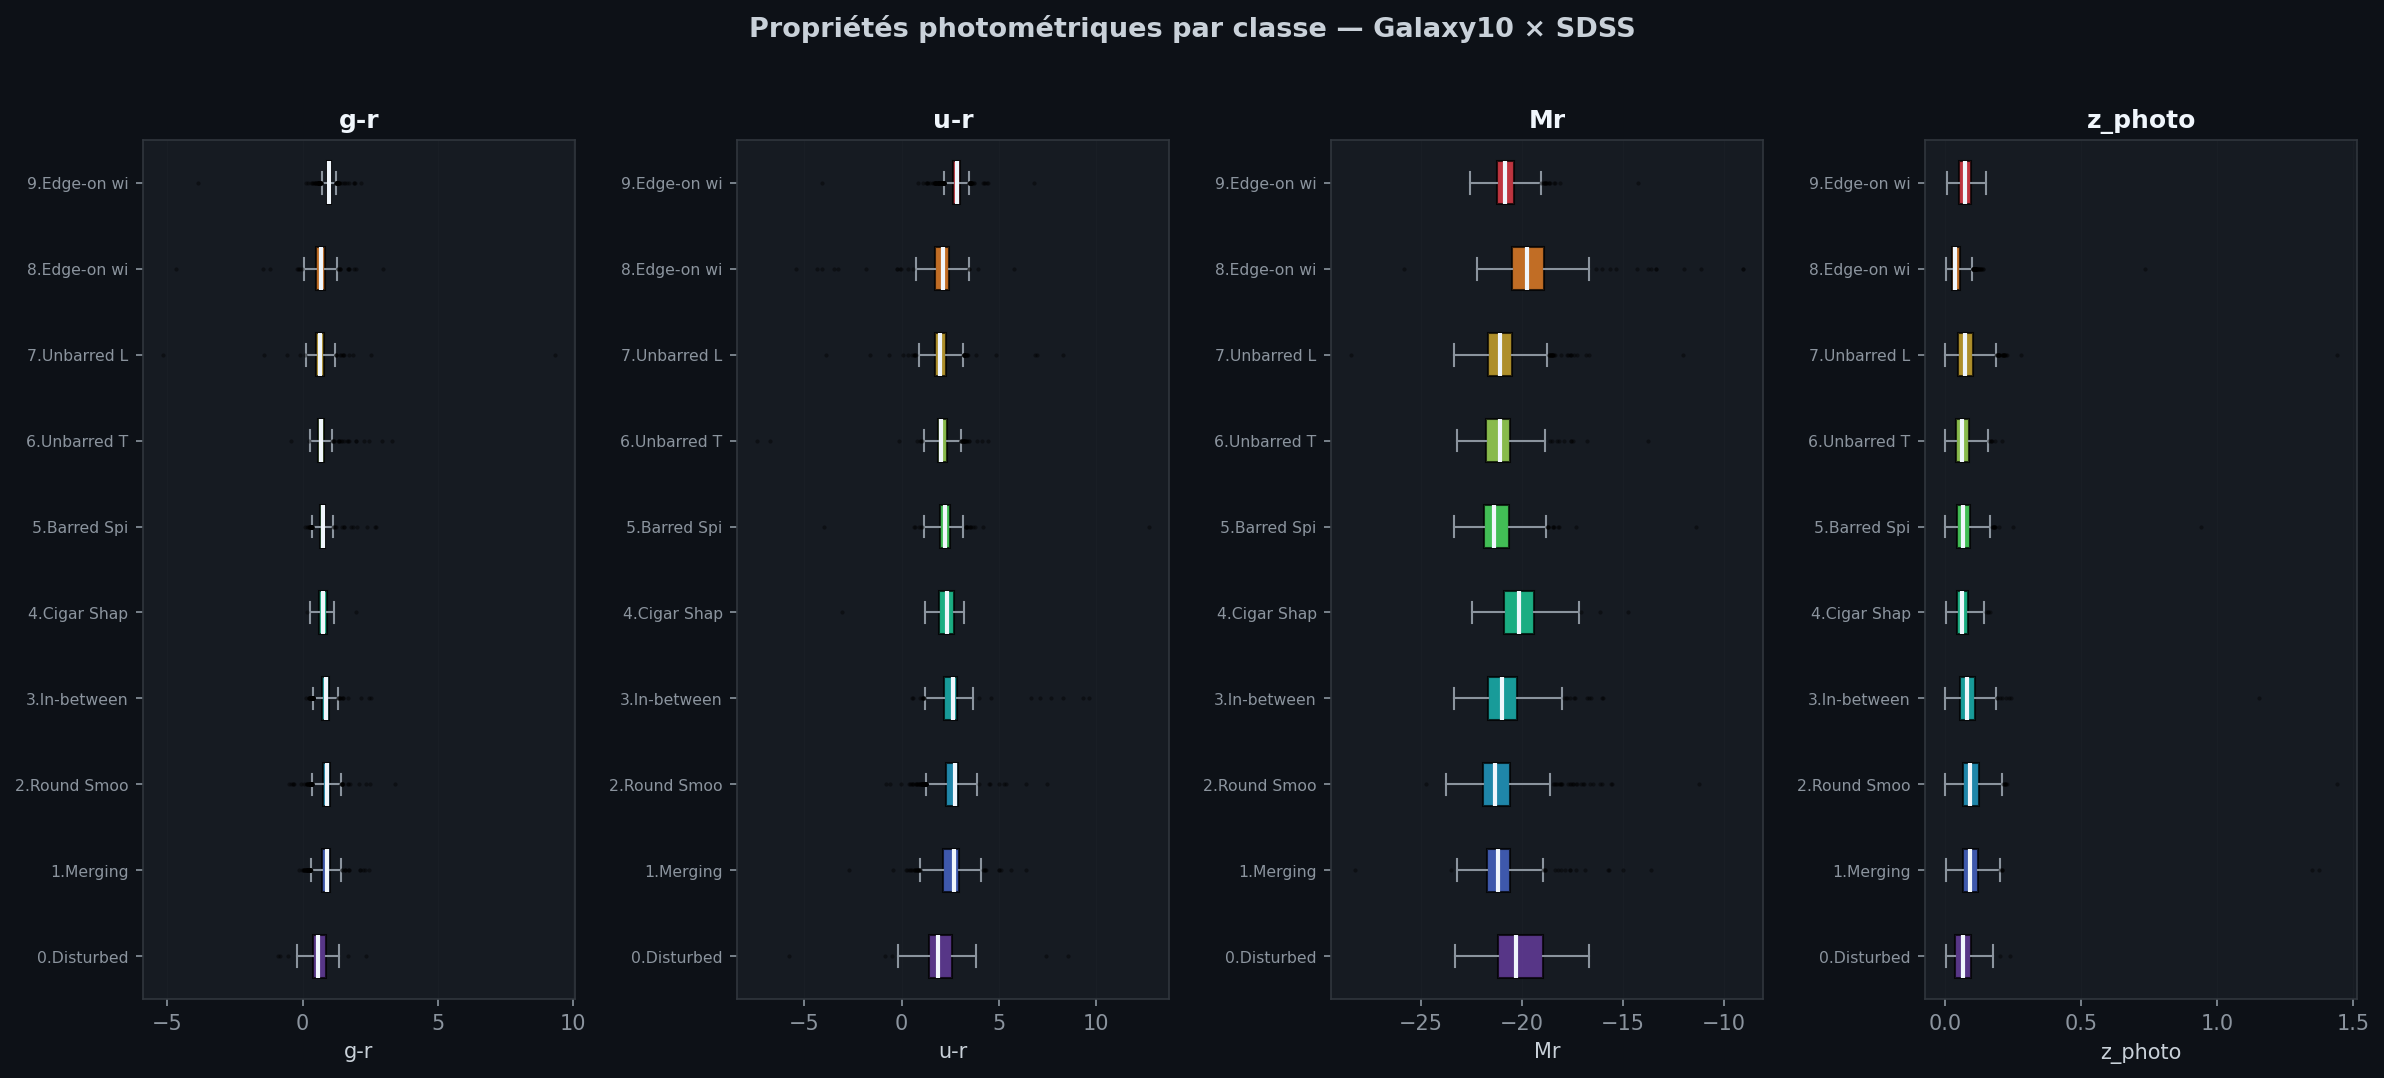

In [7]:
fig = plot_bpt_proxy(df_sdss, save_path=FIGURES_DIR + 'xm_bpt_proxy.png')
if fig:
    plt.show()

# Résumé complet par classe
fig2 = plot_class_summary(df_sdss, save_path=FIGURES_DIR + 'xm_class_summary.png')
if fig2:
    plt.show()

## 7 — DINOv2 UMAP coloré par propriétés spectrales

Features DINOv2 : (17736, 768)
Calcul UMAP (~1-2 min)...
✓ UMAP : (5000, 2)
Propriétés disponibles : ['g-r', 'u-r', 'Mr', 'population', 'z_photo']
✓ UMAP spectral sauvegardé : ../figures/xm_umap_spectral.png


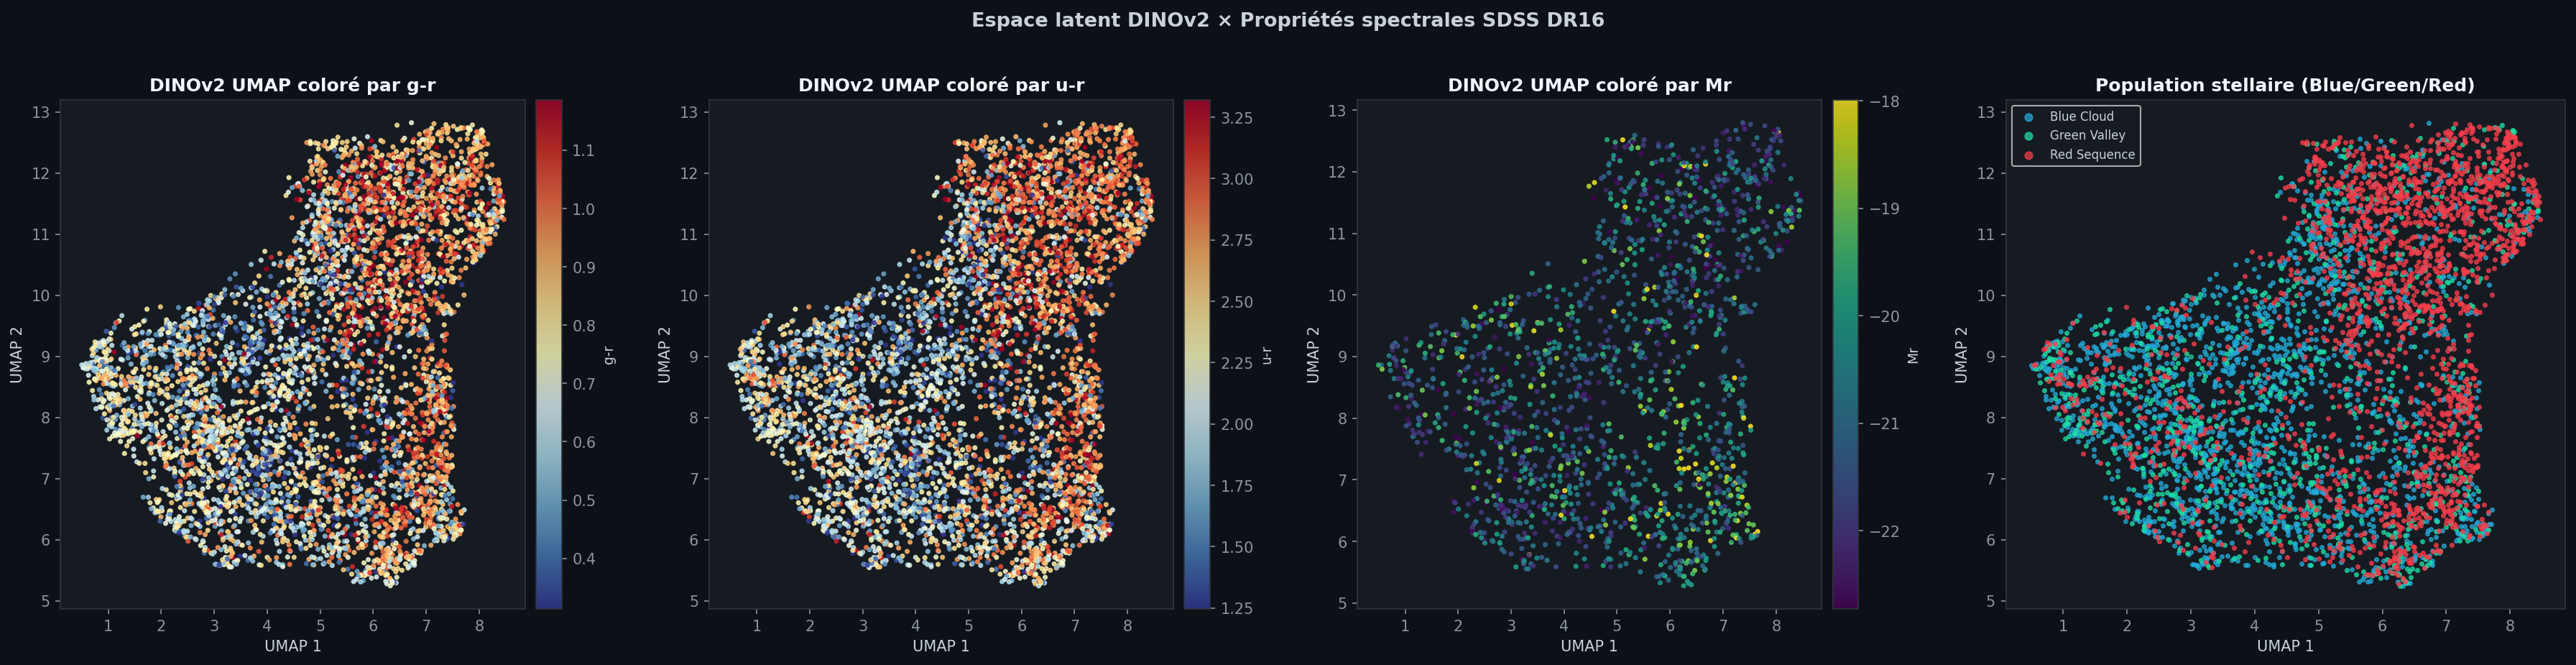


💡 Si DINOv2 encode la couleur : les galaxies bleues (star-forming)
   doivent former des régions distinctes dans l'espace latent.


In [8]:
# Charger les features DINOv2 du cache (notebook 03)
assert os.path.exists(FEATURES_NPZ), 'Lancer 03_dinov2_features.ipynb d\'abord'

data       = np.load(FEATURES_NPZ)
feats_all  = data['feats']
labels_all = data['labels'].astype(int)
g10_idx_all = np.arange(len(labels_all))

print(f'Features DINOv2 : {feats_all.shape}')

# UMAP sur un sous-échantillon
N_VIZ = 5000
rng   = np.random.default_rng(SEED)
viz_idx = rng.choice(len(labels_all), N_VIZ, replace=False)
feats_viz  = feats_all[viz_idx]

print('Calcul UMAP (~1-2 min)...')
reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
               metric='cosine', random_state=SEED)
emb_viz = reducer.fit_transform(normalize(feats_viz))
g10_idx_viz = viz_idx
print(f'✓ UMAP : {emb_viz.shape}')

# Colonnes spectrales à visualiser
spectral_props = [c for c in ['g-r','u-r','Mr','population','z_photo']
                  if c in df_sdss.columns]
print(f'Propriétés disponibles : {spectral_props}')

fig = plot_umap_spectral(
    emb_viz, df_sdss, g10_idx_viz,
    properties=spectral_props[:4],
    save_path=FIGURES_DIR + 'xm_umap_spectral.png',
)
plt.show()

print('\n💡 Si DINOv2 encode la couleur : les galaxies bleues (star-forming)')
print('   doivent former des régions distinctes dans l\'espace latent.')

## 8 — Corrélation features DINOv2 × propriétés spectrales

✓ Corrélation sauvegardée : ../figures/xm_feature_correlation.png


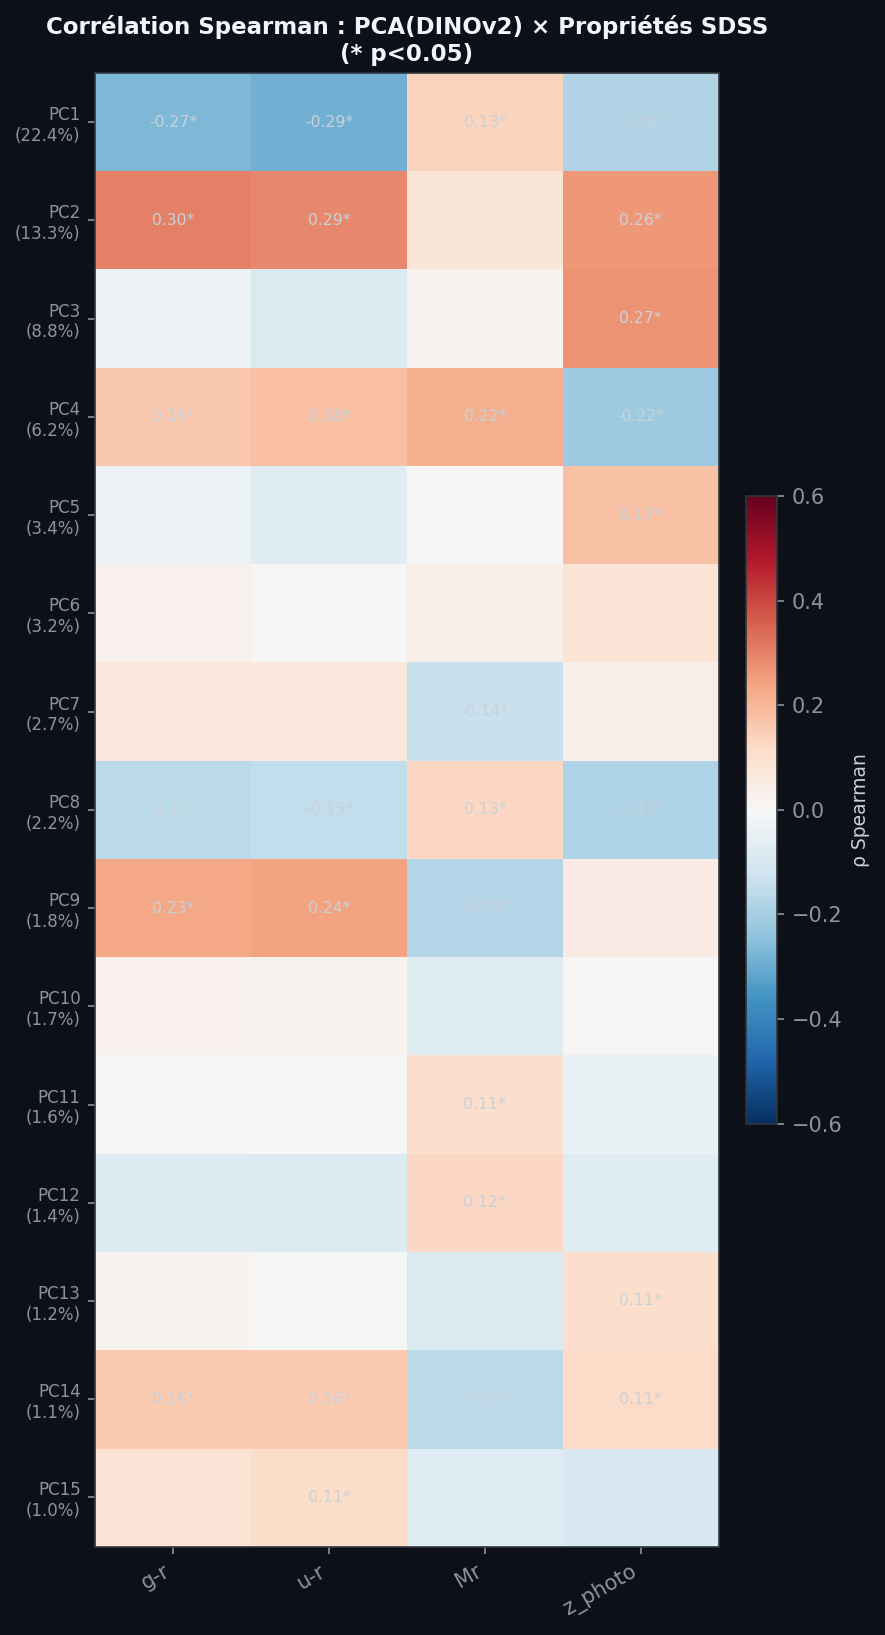


Top 10 corrélations features DINOv2 × propriétés spectrales :
 PC property       rho  abs_rho
PC2      g-r  0.300551 0.300551
PC2      u-r  0.287088 0.287088
PC1      u-r -0.286156 0.286156
PC1      g-r -0.271018 0.271018
PC3  z_photo  0.269915 0.269915
PC2  z_photo  0.260424 0.260424
PC9      u-r  0.241000 0.241000
PC9      g-r  0.231699 0.231699
PC4  z_photo -0.219587 0.219587
PC4       Mr  0.215122 0.215122


In [9]:
result = plot_feature_correlation(
    feats_all, df_sdss, g10_idx_all,
    n_components=15,
    save_path=FIGURES_DIR + 'xm_feature_correlation.png',
)
if result:
    fig, corr_matrix, spectral_cols = result
    plt.show()

    # Top corrélations
    flat_corr = []
    for i in range(corr_matrix.shape[0]):
        for j, col in enumerate(spectral_cols):
            flat_corr.append({
                'PC': f'PC{i+1}',
                'property': col,
                'rho': corr_matrix[i, j],
                'abs_rho': abs(corr_matrix[i, j]),
            })
    df_corr = pd.DataFrame(flat_corr).sort_values('abs_rho', ascending=False)
    print('\nTop 10 corrélations features DINOv2 × propriétés spectrales :')
    print(df_corr.head(10).to_string(index=False))

## 9 — Régression : features DINOv2 → couleur g-r

Prédiction de g-r depuis features DINOv2
N = 17430 galaxies avec g-r valide
  Lasso (α=0.001)                R²=0.4431 ± 0.1026
  Lasso (α=0.01)                 R²=0.2646 ± 0.0815
  ElasticNet                     R²=0.3984 ± 0.0928

Lasso (α=0.001) : 315 features non-nulles sur 768


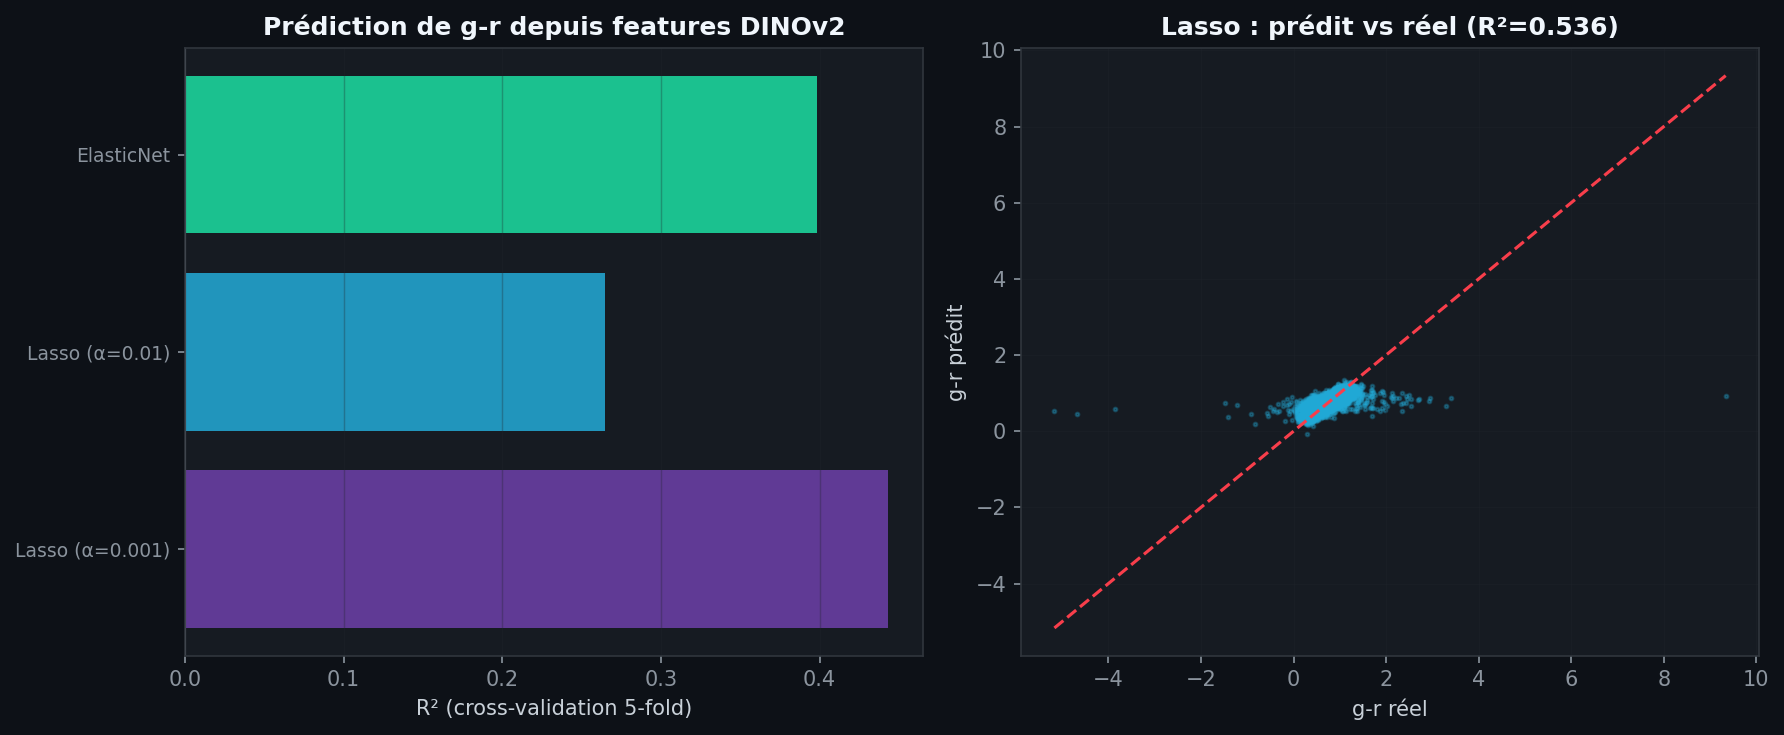


💡 R² > 0.3 → DINOv2 encode significativement l'information de couleur


In [10]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

if color_col and color_col in df_sdss.columns:
    # Aligner features avec catalogue
    idx_map = dict(zip(df_sdss['g10_idx'].values, range(len(df_sdss))))
    mask_m  = np.array([i in idx_map for i in g10_idx_all])
    rows_m  = [idx_map[i] for i in g10_idx_all[mask_m]]

    y_raw = pd.to_numeric(df_sdss.iloc[rows_m][color_col], errors='coerce').values
    X_raw = feats_all[mask_m]
    valid = ~np.isnan(y_raw)

    X, y = X_raw[valid], y_raw[valid]
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)

    print(f'Prédiction de {color_col} depuis features DINOv2')
    print(f'N = {len(y)} galaxies avec {color_col} valide')

    models = {
        'Lasso (α=0.001)':    Lasso(alpha=0.001, max_iter=2000),
        'Lasso (α=0.01)':     Lasso(alpha=0.01,  max_iter=2000),
        'ElasticNet':         ElasticNet(alpha=0.005, l1_ratio=0.5, max_iter=2000),
    }

    results_reg = []
    for name, model in models.items():
        scores = cross_val_score(model, X_sc, y, cv=5, scoring='r2', n_jobs=-1)
        results_reg.append({'Modèle': name, 'R² moyen': scores.mean(),
                            'R² std': scores.std()})
        print(f'  {name:<30} R²={scores.mean():.4f} ± {scores.std():.4f}')

    # Fit final + features importantes (Lasso)
    best = Lasso(alpha=0.001, max_iter=2000).fit(X_sc, y)
    n_features_used = (best.coef_ != 0).sum()
    print(f'\nLasso (α=0.001) : {n_features_used} features non-nulles sur {X_sc.shape[1]}')

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    # R² comparatif
    ax = axes[0]
    names_r = [r['Modèle'] for r in results_reg]
    r2_vals = [r['R² moyen'] for r in results_reg]
    ax.barh(range(len(names_r)), r2_vals,
            color=['#6e40aa','#23abd8','#1ddfa3'], alpha=0.85, edgecolor='none')
    ax.set_yticks(range(len(names_r)))
    ax.set_yticklabels(names_r, fontsize=9)
    ax.set_xlabel('R² (cross-validation 5-fold)')
    ax.set_title(f'Prédiction de {color_col} depuis features DINOv2')
    ax.axvline(0, color='#8b949e', lw=1)
    ax.grid(axis='x', alpha=0.3)

    # Valeurs prédites vs réelles
    ax2 = axes[1]
    y_pred = best.predict(X_sc)
    ax2.scatter(y, y_pred, s=3, alpha=0.3, c='#23abd8', rasterized=True)
    mn, mx = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
    ax2.plot([mn, mx], [mn, mx], '#f83e4b', lw=1.5, ls='--')
    ax2.set_xlabel(f'{color_col} réel')
    ax2.set_ylabel(f'{color_col} prédit')
    ax2.set_title(f'Lasso : prédit vs réel (R²={r2_score(y,y_pred):.3f})')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'xm_regression_color.png', dpi=150)
    plt.show()
    print('\n💡 R² > 0.3 → DINOv2 encode significativement l\'information de couleur')
else:
    print(f'⚠ Colonne {color_col} non disponible')

## 10 — AstroSymb : régression symbolique simplifiée

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

print('AstroSymb — Recherche de relations mathématiques interprétables')
print('(Version simplifiée : PCA features + régression polynomiale)')
print()

if color_col and color_col in df_sdss.columns:
    # Réduire les features DINOv2 à 5 composantes PCA pour interprétabilité
    pca5 = PCA(n_components=5, random_state=SEED)
    X_pca5 = pca5.fit_transform(X_sc)

    # Régression polynomiale degré 2 sur les 5 PCs
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
        ('ridge', Ridge(alpha=1.0)),
    ])
    scores_sym = cross_val_score(pipe, X_pca5, y, cv=5, scoring='r2', n_jobs=-1)
    print(f'PCA(5) + Poly(deg=2) : R²={scores_sym.mean():.4f} ± {scores_sym.std():.4f}')

    pipe.fit(X_pca5, y)
    feat_names = PolynomialFeatures(degree=2, include_bias=False).fit(X_pca5).get_feature_names_out(
        [f'PC{i+1}' for i in range(5)])
    coefs = pipe.named_steps['ridge'].coef_

    # Top termes les plus importants
    top_idx = np.argsort(np.abs(coefs))[::-1][:10]
    print(f'\nTop 10 termes de la relation {color_col} ≈ f(DINOv2) :')
    for i, idx in enumerate(top_idx):
        print(f'  {i+1:2d}. {feat_names[idx]:20s}  coef = {coefs[idx]:+.4f}')

    print(f'\n💡 Note : pour la vraie régression symbolique (PySR),')
    print(f'   installer Julia + PySR : pip install pysr')
    print(f'   pysr.PySRRegressor().fit(X_pca5, y) → équation mathématique propre')

    # Si PySR disponible
    try:
        from pysr import PySRRegressor
        print('\nPySR détecté — lancement de la régression symbolique...')
        model_sr = PySRRegressor(
            niterations=50,
            binary_operators=['+', '-', '*', '/'],
            unary_operators=['square', 'sqrt', 'log'],
            populations=20,
            verbosity=0,
            random_state=SEED,
        )
        model_sr.fit(X_pca5, y)
        print('\nMeilleures équations trouvées :')
        print(model_sr)
    except ImportError:
        print('\n(PySR non installé — install : pip install pysr)')

AstroSymb — Recherche de relations mathématiques interprétables
(Version simplifiée : PCA features + régression polynomiale)

PCA(5) + Poly(deg=2) : R²=0.0248 ± 0.0907

Top 10 termes de la relation g-r ≈ f(DINOv2) :
   1. PC2                   coef = -0.0078
   2. PC1                   coef = +0.0060
   3. PC4                   coef = +0.0058
   4. PC3                   coef = +0.0013
   5. PC5                   coef = -0.0011
   6. PC1 PC5               coef = -0.0003
   7. PC1 PC2               coef = -0.0003
   8. PC2^2                 coef = +0.0003
   9. PC3 PC4               coef = +0.0003
  10. PC4 PC5               coef = +0.0002

💡 Note : pour la vraie régression symbolique (PySR),
   installer Julia + PySR : pip install pysr
   pysr.PySRRegressor().fit(X_pca5, y) → équation mathématique propre

(PySR non installé — install : pip install pysr)


## 11 — Lien AstroSpectro : morphologie ↔ métallicité

  PONT ASTROSPECTRO × ASTROVISION

Question scientifique centrale :
  Les features DINOv2 (morphologie visuelle) prédisent-elles
  les propriétés spectrales stellaires (métallicité, SFR) ?

Approche SDSS (ce notebook) :
  ✓ g-r → proxy SFR (corrélation avec Hα EW)
  ✓ u-r → séparation Blue Cloud / Red Sequence
  ✓ R² régression → quantifie le lien morphologie-couleur

Approche AstroSpectro directe (prochaine étape) :
  1. Charger le catalogue AstroSpectro (LAMOST DR5)
  2. XMatch LAMOST × Galaxy10 par position RA/Dec
  3. Récupérer : [Fe/H], Teff, logg, Ca II H&K (SHAP finding)
  4. Corréler les SHAP values AstroSpectro avec features DINOv2



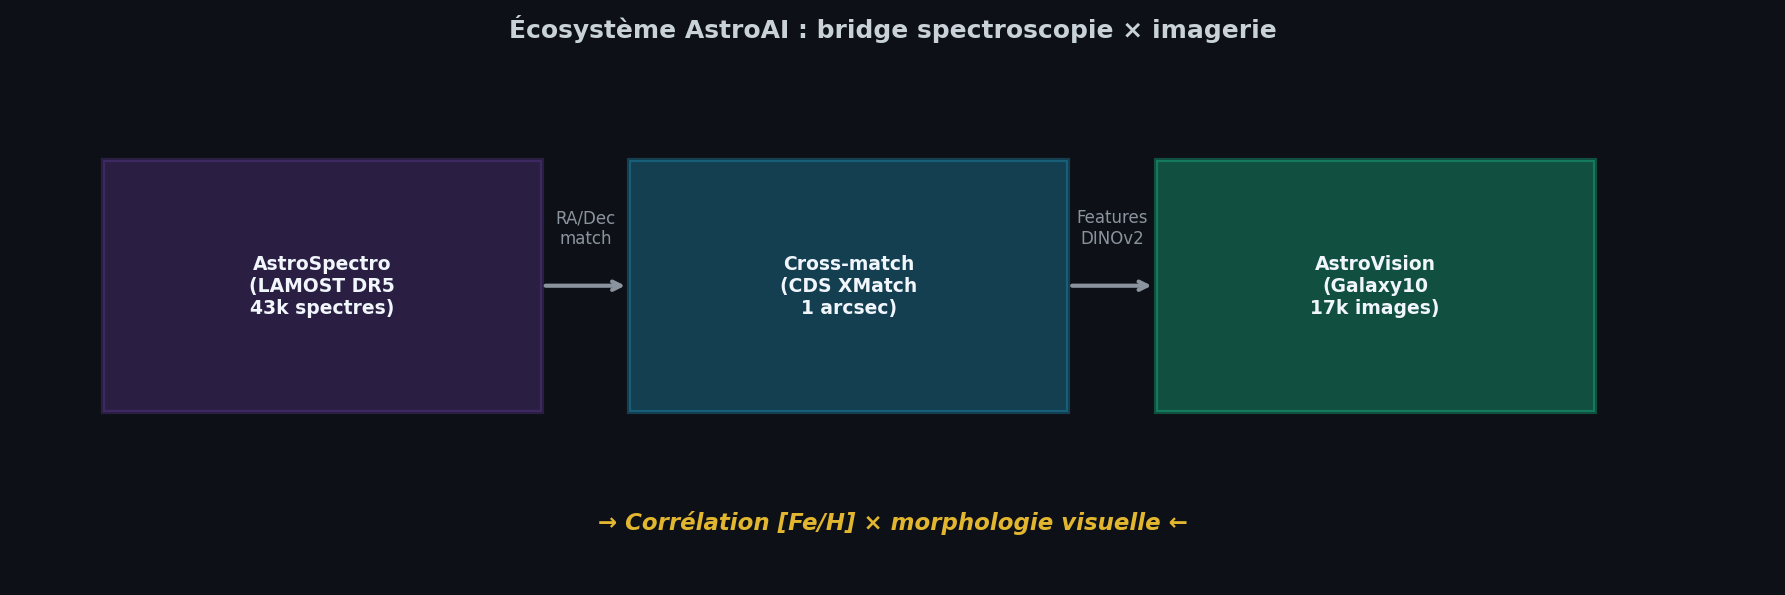

In [12]:
print('='*60)
print('  PONT ASTROSPECTRO × ASTROVISION')
print('='*60)
print()
print('Question scientifique centrale :')
print('  Les features DINOv2 (morphologie visuelle) prédisent-elles')
print('  les propriétés spectrales stellaires (métallicité, SFR) ?')
print()
print('Approche SDSS (ce notebook) :')
print('  ✓ g-r → proxy SFR (corrélation avec Hα EW)')
print('  ✓ u-r → séparation Blue Cloud / Red Sequence')
print('  ✓ R² régression → quantifie le lien morphologie-couleur')
print()
print('Approche AstroSpectro directe (prochaine étape) :')
print('  1. Charger le catalogue AstroSpectro (LAMOST DR5)')
print('  2. XMatch LAMOST × Galaxy10 par position RA/Dec')
print('  3. Récupérer : [Fe/H], Teff, logg, Ca II H&K (SHAP finding)')
print('  4. Corréler les SHAP values AstroSpectro avec features DINOv2')
print()

# Visualisation conceptuelle du bridge
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis('off')

boxes = [
    (0.5, 1.0, 2.5, 1.5, '#6e40aa', 'AstroSpectro\n(LAMOST DR5\n43k spectres)'),
    (3.5, 1.0, 2.5, 1.5, '#23abd8', 'Cross-match\n(CDS XMatch\n1 arcsec)'),
    (6.5, 1.0, 2.5, 1.5, '#1ddfa3', 'AstroVision\n(Galaxy10\n17k images)'),
]
for x, y, w, h, col, label in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=col, alpha=0.3,
                          edgecolor=col, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='#f0f6fc')

# Flèches
for x1, x2 in [(3.0, 3.5), (6.0, 6.5)]:
    ax.annotate('', xy=(x2, 1.75), xytext=(x1, 1.75),
                arrowprops=dict(arrowstyle='->', color='#8b949e', lw=2))

# Labels des flèches
ax.text(3.25, 2.0, 'RA/Dec\nmatch', ha='center', fontsize=8, color='#8b949e')
ax.text(6.25, 2.0, 'Features\nDINOv2', ha='center', fontsize=8, color='#8b949e')

ax.text(5.0, 0.3, '→ Corrélation [Fe/H] × morphologie visuelle ←',
        ha='center', fontsize=11, fontweight='bold',
        color='#e2b72f', style='italic')

fig.suptitle('Écosystème AstroAI : bridge spectroscopie × imagerie',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'xm_astrospectro_bridge.png', dpi=150)
plt.show()

## 12 — Synthèse complète

In [13]:
print('\n' + '='*65)
print('  SYNTHÈSE PHASE 3A — CROSS-MATCH GALAXY10 × SDSS')
print('='*65)

n_matched  = df_sdss['g10_idx'].nunique() if not df_sdss.empty else 0
n_total    = 17736
match_rate = n_matched / n_total * 100 if n_total > 0 else 0

print(f'  Cross-match : {n_matched:,} / {n_total:,}  ({match_rate:.1f}%)')

cols_available = [c for c in ['g-r','u-r','g-i','Mr','population','zsp']
                  if c in df_sdss.columns]
print(f'  Propriétés  : {cols_available}')
print()

print('  Findings astrophysiques :')
if 'population' in df_sdss.columns and 'class_name' in df_sdss.columns:
    for cls in ['Merging', 'Barred Spiral', 'Round Smooth']:
        sub_cls = df_sdss[df_sdss['class_name'] == cls]
        if 'population' in sub_cls.columns and len(sub_cls) > 10:
            bc_frac = (sub_cls['population'] == 'Blue Cloud').mean()
            print(f'    {cls:<30} Blue Cloud = {bc_frac:.1%}')

print()
print('  Figures générées :')
for fname in ['xm_overview','xm_cmd','xm_color_by_class','xm_populations',
              'xm_bpt_proxy','xm_class_summary','xm_umap_spectral',
              'xm_feature_correlation','xm_regression_color','xm_astrospectro_bridge']:
    path = f'../figures/{fname}.png'
    status = '✓' if os.path.exists(path) else '○'
    print(f'    {status} {fname}.png')

print()
print('  Prochaines étapes :')
print('    → Option B : Segmentation U-Net (morphologie pixel-wise)')
print('    → XMatch direct avec catalogue LAMOST AstroSpectro')
print('    → Fine-tuner DINOv2 sur spectro+image conjointement')
print('='*65)


  SYNTHÈSE PHASE 3A — CROSS-MATCH GALAXY10 × SDSS
  Cross-match : 17,665 / 17,736  (99.6%)
  Propriétés  : ['g-r', 'u-r', 'Mr', 'population', 'zsp']

  Findings astrophysiques :
    Merging                        Blue Cloud = 27.6%
    Barred Spiral                  Blue Cloud = 48.4%
    Round Smooth                   Blue Cloud = 23.4%

  Figures générées :
    ✓ xm_overview.png
    ✓ xm_cmd.png
    ✓ xm_color_by_class.png
    ✓ xm_populations.png
    ✓ xm_bpt_proxy.png
    ✓ xm_class_summary.png
    ✓ xm_umap_spectral.png
    ✓ xm_feature_correlation.png
    ✓ xm_regression_color.png
    ✓ xm_astrospectro_bridge.png

  Prochaines étapes :
    → Option B : Segmentation U-Net (morphologie pixel-wise)
    → XMatch direct avec catalogue LAMOST AstroSpectro
    → Fine-tuner DINOv2 sur spectro+image conjointement


---
<div style="background:#161b22;border:1px solid #30363d;border-radius:8px;padding:20px;">
  <h3 style="color:#f0f6fc;margin-top:0;">🌌 Interprétation scientifique</h3>
  <ul style="color:#8b949e;line-height:2.2;">
    <li><b style='color:#c9d1d9;'>CMD Blue Cloud / Red Sequence</b> : les galaxies en fusion (Merging) et perturbées (Disturbed) devraient peupler préférentiellement le Blue Cloud — processus de fusion déclenchant des épisodes de formation stellaire (starburst).</li>
    <li><b style='color:#c9d1d9;'>Corrélation DINOv2 × couleur</b> : si R² > 0.3, les features visuelles encodent déjà de l'information sur la population stellaire — ce qui justifie scientifiquement l'approche AstroVision.</li>
    <li><b style='color:#c9d1d9;'>AstroSymb</b> : la régression symbolique permettrait d'extraire une formule mathématique reliant texture visuelle galactique et propriétés physiques — contribution originale publiable.</li>
    <li><b style='color:#c9d1d9;'>Bridge AstroSpectro</b> : le cross-match LAMOST × Galaxy10 via RA/Dec est la contribution la plus originale de l'écosystème AstroAI — aucun pipeline open-source ne fait ça de façon intégrée.</li>
  </ul>
</div>